# ICU Patient Phenotypes from MIMIC-III: Vitals vs. Comorbidities

This notebook uses clustering to identify groups of ICU patients with similar characteristics.

I compare two feature sets:

* Vitals and lab measurements from the first 24 hours of the ICU stay
* Patient comorbidities

The goal is to see whether these two types of data produce similar patient groups and whether the clusters differ in outcomes such as mortality and length of stay.


## 1. Install the libraries we need

In [ ]:
# pandas/numpy handle the data, scikit-learn does the clustering and scaling,
# scipy runs the statistical tests, matplotlib/seaborn make the plots.
!pip -q install --upgrade scikit-learn scipy matplotlib seaborn pandas umap-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy import stats

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False

# fixed seed so the clustering comes out the same way every time we run it
SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")


## 2. Connect to BigQuery

MIMIC-III is hosted on BigQuery. This logs in and opens a connection so we can query it directly from the notebook.

In [ ]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

PROJECT_ID = 'mc-ut-msai-aih-1'  # change this to your own BigQuery project ID
client = bigquery.Client(project=PROJECT_ID)

test_query = "SELECT COUNT(*) AS total FROM `physionet-data.mimiciii_clinical.icustays`"
print(client.query(test_query).to_dataframe())


   total
0  61532


## 3. Build the cohort

One row in the dataset represents one ICU stay. I use only the first ICU stay for each patient to avoid having the same patient represented multiple times.

Other cohort rules:

* Adults only (age 18+ at ICU admission)
* ICU stay of at least 24 hours, since the analysis uses data from the first 24 hours
* Newborn admissions are excluded


In [ ]:
cohort_query = """
WITH icu_ranked AS (
  SELECT
    i.subject_id, i.hadm_id, i.icustay_id, i.intime, i.outtime,
    TIMESTAMP_DIFF(i.outtime, i.intime, HOUR) AS los_hours,
    ROW_NUMBER() OVER (PARTITION BY i.subject_id ORDER BY i.intime) AS stay_rank
  FROM `physionet-data.mimiciii_clinical.icustays` i
)
SELECT
  r.subject_id, r.hadm_id, r.icustay_id, r.intime, r.los_hours,
  LEAST(DATE_DIFF(DATE(r.intime), DATE(p.dob), YEAR), 90) AS age,
  p.gender,
  a.hospital_expire_flag,
  a.admission_type
FROM icu_ranked r
JOIN `physionet-data.mimiciii_clinical.patients` p ON r.subject_id = p.subject_id
JOIN `physionet-data.mimiciii_clinical.admissions` a ON r.hadm_id = a.hadm_id
WHERE r.stay_rank = 1
  AND r.los_hours >= 24
  AND a.admission_type != 'NEWBORN'
  AND DATE_DIFF(DATE(r.intime), DATE(p.dob), YEAR) >= 18
"""

cohort = client.query(cohort_query).to_dataframe()
print(f"Cohort size: {len(cohort):,} ICU stays")
cohort.head()


Cohort size: 33,011 ICU stays


,subject_id,hadm_id,icustay_id,intime,los_hours,age,gender,hospital_expire_flag,admission_type
0,43,146828,225852,2186-10-01 23:16:40,111,33,M,0,EMERGENCY
1,64,172056,232593,2143-03-03 09:26:21,56,27,F,0,EMERGENCY
2,65,143430,244776,2132-08-10 07:13:42,80,26,M,0,EMERGENCY
3,88,123010,297289,2111-08-29 03:04:42,42,29,M,0,EMERGENCY
4,105,161160,294980,2189-01-28 16:59:55,120,36,F,0,EMERGENCY


In [ ]:
funnel_query = """
WITH icu_ranked AS (
  SELECT
    i.subject_id, i.hadm_id, i.icustay_id, i.intime,
    TIMESTAMP_DIFF(i.outtime, i.intime, HOUR) AS los_hours,
    ROW_NUMBER() OVER (PARTITION BY i.subject_id ORDER BY i.intime) AS stay_rank
  FROM `physionet-data.mimiciii_clinical.icustays` i
)
SELECT
  COUNT(*) AS all_icu_stays,
  COUNTIF(r.stay_rank = 1) AS after_first_stay_only,
  COUNTIF(r.stay_rank = 1 AND r.los_hours >= 24) AS after_los_filter,
  COUNTIF(r.stay_rank = 1 AND r.los_hours >= 24 AND a.admission_type != 'NEWBORN') AS after_newborn_filter,
  COUNTIF(r.stay_rank = 1 AND r.los_hours >= 24 AND a.admission_type != 'NEWBORN'
          AND DATE_DIFF(DATE(r.intime), DATE(p.dob), YEAR) >= 18) AS after_adult_filter
FROM icu_ranked r
JOIN `physionet-data.mimiciii_clinical.patients` p ON r.subject_id = p.subject_id
JOIN `physionet-data.mimiciii_clinical.admissions` a ON r.hadm_id = a.hadm_id
"""

client.query(funnel_query).to_dataframe().T.rename(columns={0: "n_stays"})


,n_stays
all_icu_stays,61532
after_first_stay_only,46476
after_los_filter,36832
after_newborn_filter,33132
after_adult_filter,33011


## 4. Feature set 1: vitals and labs (first 24 hours)

Vital signs are measured multiple times during the first 24 hours of an ICU stay. For each vital, I calculate the mean, minimum, maximum, and standard deviation.

Values outside reasonable physiological ranges are excluded before calculating these statistics to reduce the effect of possible charting errors.


In [ ]:
# (name, itemids, plausible_min, plausible_max) - the range keeps obvious
# charting errors out of the AVG/MIN/MAX/STDDEV before they're even computed
VITAL_SPECS = [
    ("heart_rate", [211, 220045],                    0,   300),
    ("resp_rate",  [618, 615, 220210, 224690],        0,   80),
    ("sbp",        [51, 442, 455, 6701, 220179, 220050], 0, 300),
    ("dbp",        [8368, 8440, 8441, 8555, 220180, 220051], 0, 200),
    ("temp_c",     [676, 223762],                     25,  45),
    ("spo2",       [646, 220277],                     0,   100),
    ("gcs",        [198, 226755],                     3,   15),
]

vital_cases = "\n  ".join(
    f"WHEN itemid IN ({','.join(map(str, ids))}) AND valuenum BETWEEN {lo} AND {hi} THEN '{name}'"
    for name, ids, lo, hi in VITAL_SPECS
)
all_vital_ids = sorted({i for _, ids, _, _ in VITAL_SPECS for i in ids})

vitals_query = f"""
WITH tagged AS (
  SELECT
    c.icustay_id,
    CASE {vital_cases} END AS vital,
    c.valuenum
  FROM `physionet-data.mimiciii_clinical.chartevents` c
  JOIN `physionet-data.mimiciii_clinical.icustays` i ON c.icustay_id = i.icustay_id
  WHERE c.itemid IN ({','.join(map(str, all_vital_ids))})
    AND c.valuenum IS NOT NULL
    AND c.charttime BETWEEN i.intime AND TIMESTAMP_ADD(i.intime, INTERVAL 24 HOUR)
)
SELECT
  icustay_id, vital,
  AVG(valuenum) AS mean_val,
  MIN(valuenum) AS min_val,
  MAX(valuenum) AS max_val,
  STDDEV(valuenum) AS std_val
FROM tagged
WHERE vital IS NOT NULL  -- drops rows outside the plausible range for their vital
GROUP BY icustay_id, vital
"""

vitals_long = client.query(vitals_query).to_dataframe()
print(f"Rows: {len(vitals_long):,}")
vitals_long.head()


Rows: 303,602


,icustay_id,vital,mean_val,min_val,max_val,std_val
0,278355,gcs,5.857143,5.0,7.0,1.069045
1,281650,resp_rate,15.500000,2.0,20.0,3.929942
2,213268,resp_rate,16.560976,5.0,25.0,4.006550
3,297469,resp_rate,16.000000,5.0,24.0,4.423524
4,265221,resp_rate,26.291667,21.0,31.0,2.758058


In [ ]:
# reshape from one-row-per-(icustay, vital) to one-row-per-icustay,
# with columns like heart_rate_mean, heart_rate_min, ...
vitals_wide = vitals_long.pivot(index="icustay_id", columns="vital",
                                 values=["mean_val", "min_val", "max_val", "std_val"])
vitals_wide.columns = [f"{v}_{stat.replace('_val','')}" for stat, v in vitals_wide.columns]
vitals_wide = vitals_wide.reset_index()

print(f"Vitals feature table: {vitals_wide.shape}")
vitals_wide.head()


Vitals feature table: (59057, 29)


,icustay_id,dbp_mean,gcs_mean,heart_rate_mean,resp_rate_mean,sbp_mean,spo2_mean,temp_c_mean,dbp_min,gcs_min,...,sbp_max,spo2_max,temp_c_max,dbp_std,gcs_std,heart_rate_std,resp_rate_std,sbp_std,spo2_std,temp_c_std
0,200001,57.346154,NaN,100.760000,21.230769,103.423077,98.076923,NaN,49.0,NaN,...,118.0,100.0,NaN,5.214919,NaN,10.798457,4.777511,8.700221,2.279001,NaN
1,200003,53.384615,11.500000,99.386364,28.978261,87.307692,95.533333,NaN,0.0,3.0,...,141.0,98.0,NaN,24.391540,4.985694,15.591017,7.590898,39.505045,2.180492,NaN
2,200006,57.545455,15.000000,74.136364,19.964286,107.636364,98.541667,NaN,45.0,15.0,...,118.0,100.0,NaN,10.777964,0.000000,5.036017,3.202801,8.381075,1.587428,NaN
3,200007,58.285714,15.000000,94.064516,21.520000,115.000000,95.750000,NaN,32.0,15.0,...,144.0,97.0,NaN,13.218554,0.000000,6.016286,3.618471,14.727148,1.164965,NaN
4,200009,62.500000,7.571429,95.774194,15.918919,100.781250,99.848485,37.245161,49.0,3.0,...,130.0,100.0,38.299999,10.785295,3.309438,5.542019,2.228332,13.670629,0.870388,1.136321


Before clustering, I review the summary statistics to check for implausible values or remaining outliers.


In [ ]:
# same idea as the vitals query - keep a plausible range per lab so a single
# entry error (e.g. a misplaced decimal) can't blow up that patient's stats
LAB_SPECS = [
    ("creatinine",  [50912], 0,   30),
    ("wbc",         [51301], 0,   200),
    ("lactate",     [50813], 0,   30),
    ("glucose",     [50931], 0,   2000),
    ("bicarbonate", [50882], 0,   60),
    ("potassium",   [50971], 0,   15),
    ("hemoglobin",  [51222], 0,   25),
]
lab_cases = "\n  ".join(
    f"WHEN itemid IN ({','.join(map(str, ids))}) AND valuenum BETWEEN {lo} AND {hi} THEN '{name}'"
    for name, ids, lo, hi in LAB_SPECS
)
all_lab_ids = sorted({i for _, ids, _, _ in LAB_SPECS for i in ids})

labs_query = f"""
WITH tagged AS (
  SELECT
    l.hadm_id,
    CASE {lab_cases} END AS lab,
    l.valuenum
  FROM `physionet-data.mimiciii_clinical.labevents` l
  JOIN `physionet-data.mimiciii_clinical.icustays` i ON l.hadm_id = i.hadm_id
  WHERE l.itemid IN ({','.join(map(str, all_lab_ids))})
    AND l.valuenum IS NOT NULL
    AND l.charttime BETWEEN i.intime AND TIMESTAMP_ADD(i.intime, INTERVAL 24 HOUR)
)
SELECT hadm_id, lab, AVG(valuenum) AS mean_val, MIN(valuenum) AS min_val, MAX(valuenum) AS max_val
FROM tagged
WHERE lab IS NOT NULL
GROUP BY hadm_id, lab
"""

labs_long = client.query(labs_query).to_dataframe()
labs_wide = labs_long.pivot(index="hadm_id", columns="lab", values=["mean_val", "min_val", "max_val"])
labs_wide.columns = [f"{l}_{stat.replace('_val','')}" for stat, l in labs_wide.columns]
labs_wide = labs_wide.reset_index()

print(f"Labs feature table: {labs_wide.shape}")
labs_wide.head()


Labs feature table: (53733, 22)


,hadm_id,bicarbonate_mean,creatinine_mean,glucose_mean,hemoglobin_mean,lactate_mean,potassium_mean,wbc_mean,bicarbonate_min,creatinine_min,...,lactate_min,potassium_min,wbc_min,bicarbonate_max,creatinine_max,glucose_max,hemoglobin_max,lactate_max,potassium_max,wbc_max
0,100001,18.75,2.30,151.0,11.150000,NaN,4.075,10.800000,17.0,2.2,...,NaN,3.8,10.4,21.0,2.4,185.0,11.3,NaN,4.2,11.2
1,100003,15.50,1.15,84.5,9.166667,1.1,5.000,13.933333,15.0,1.1,...,1.1,5.0,13.4,16.0,1.2,113.0,10.4,1.1,5.0,14.2
2,100006,24.00,0.60,129.0,10.300000,NaN,3.700,13.600000,24.0,0.6,...,NaN,3.7,13.6,24.0,0.6,129.0,10.3,NaN,3.7,13.6
3,100007,26.00,0.65,126.0,11.800000,NaN,4.400,10.550000,25.0,0.6,...,NaN,4.1,8.8,27.0,0.7,137.0,12.3,NaN,4.7,12.3
4,100009,23.50,0.80,177.0,12.966667,1.3,4.200,14.466667,23.0,0.8,...,1.1,4.0,12.3,24.0,0.8,177.0,13.7,1.5,4.4,17.3


## 5. Feature set 2: comorbidities from diagnosis codes

Comorbidities are chronic conditions that a patient has in addition to the condition that brought them to the ICU.

I use ICD-9 diagnosis codes to identify common comorbidities such as diabetes, heart failure, and kidney disease. Each comorbidity is represented as a binary feature: 1 if the patient has the condition and 0 if not.

A simplified subset of the Elixhauser comorbidity categories is used for this analysis.


In [ ]:
COMORBIDITY_PREFIXES = {
    "congestive_heart_failure": ["428"],
    "cardiac_arrhythmia":       ["4273", "4270", "4272"],
    "hypertension":             ["401"],
    "chronic_pulmonary_disease":["490","491","492","493","494","495","496"],
    "diabetes":                 ["250"],
    "renal_failure":            ["585","586"],
    "liver_disease":            ["570","571","572"],
    "metastatic_cancer":        ["196","197","198","199"],
    "solid_tumor":              ["140","141","142","143","144","145","146","147","148","149",
                                  "150","151","152","153","154","155","156","157","158","159"],
    "coagulopathy":             ["286"],
    "obesity":                  ["2780"],
    "fluid_electrolyte":        ["2760","2761","2762","2763","2764","2765","2766","2767","2768","2769"],
    "anemia":                   ["280","281","282","283","284","285"],
    "alcohol_abuse":            ["3050","291"],
    "depression":               ["2962","2963","311"],
}

# build one CASE WHEN per category, matching on ICD9 code prefix with STARTS_WITH
case_lines = []
for name, prefixes in COMORBIDITY_PREFIXES.items():
    conditions = " OR ".join(f"STARTS_WITH(icd9_code, '{p}')" for p in prefixes)
    case_lines.append(f"MAX(CASE WHEN {conditions} THEN 1 ELSE 0 END) AS {name}")
case_sql = ",\n  ".join(case_lines)

comorbidity_query = f"""
SELECT
  hadm_id,
  {case_sql}
FROM `physionet-data.mimiciii_clinical.diagnoses_icd`
GROUP BY hadm_id
"""

comorbidities = client.query(comorbidity_query).to_dataframe()
print(f"Comorbidity feature table: {comorbidities.shape}")
comorbidities.head()


Comorbidity feature table: (58976, 16)


,hadm_id,congestive_heart_failure,cardiac_arrhythmia,hypertension,chronic_pulmonary_disease,diabetes,renal_failure,liver_disease,metastatic_cancer,solid_tumor,coagulopathy,obesity,fluid_electrolyte,anemia,alcohol_abuse,depression
0,108811,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0
1,153771,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0
2,155415,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
3,188869,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
4,102509,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 6. Put it together, and look at the data before modeling

The two feature sets are combined with the cohort data. Before modeling, I review the outcomes and missing values to better understand the final dataset.


In [ ]:
features = cohort.merge(vitals_wide, on="icustay_id", how="left")
features = features.merge(labs_wide, on="hadm_id", how="left")
features = features.merge(comorbidities, on="hadm_id", how="left")

vital_lab_cols = [c for c in list(vitals_wide.columns) + list(labs_wide.columns)
                  if c not in ("icustay_id", "hadm_id")]
comorbidity_cols = [c for c in comorbidities.columns if c != "hadm_id"]

print(f"Combined table: {features.shape}")
print(f"Vitals/labs columns: {len(vital_lab_cols)}")
print(f"Comorbidity columns: {len(comorbidity_cols)}")


Combined table: (33011, 73)
Vitals/labs columns: 49
Comorbidity columns: 15


Before clustering, I review the summary statistics to check for implausible values or remaining outliers.


In [ ]:
features[vital_lab_cols].describe().T[["mean", "min", "max"]].round(1)


,mean,min,max
dbp_mean,60.6,12.4,129.6
gcs_mean,11.9,3.0,15.0
heart_rate_mean,85.6,31.2,155.0
resp_rate_mean,18.6,2.3,42.3
sbp_mean,119.0,25.0,197.4
spo2_mean,97.3,9.6,100.0
temp_c_mean,36.9,30.4,40.1
dbp_min,42.4,0.0,127.0
gcs_min,9.6,3.0,15.0
heart_rate_min,70.9,0.0,140.0


I also check values near the clipping boundaries used in Section 4 to make sure the selected ranges are reasonable.


In [ ]:
near_ceiling = features[features["heart_rate_max"] >= 299]
print(f"Stays with heart_rate_max >= 299: {len(near_ceiling)} (out of {len(features):,})")
near_ceiling[["icustay_id", "heart_rate_max", "hospital_expire_flag"]]


Stays with heart_rate_max >= 299: 1 (out of 33,011)


,icustay_id,heart_rate_max,hospital_expire_flag
19152,295350,300.0,0


hospital_expire_flag
0    0.892
1    0.108
Name: proportion, dtype: Float64


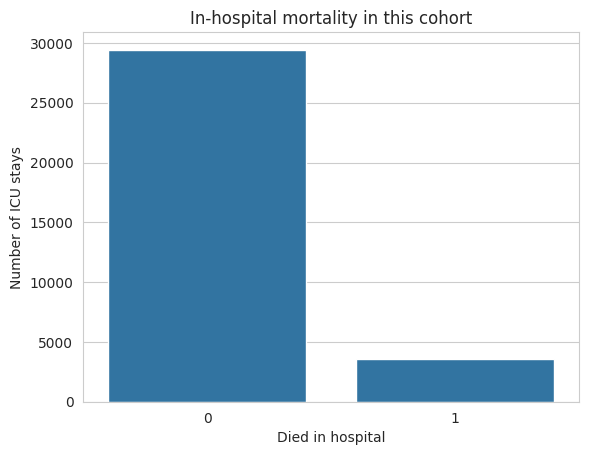

In [ ]:
print(features["hospital_expire_flag"].value_counts(normalize=True).round(3))

sns.countplot(data=features, x="hospital_expire_flag")
plt.title("In-hospital mortality in this cohort")
plt.xlabel("Died in hospital")
plt.ylabel("Number of ICU stays")
plt.show()


In [ ]:
# drop stays missing more than half of their vitals/labs features - a small number,
# safe to remove rather than impute over that much missing data
missing_frac = features[vital_lab_cols].isna().mean(axis=1)
features = features[missing_frac <= 0.5].reset_index(drop=True)

# comorbidity flags should never be missing (GROUP BY guarantees a row per hadm_id
# that has any diagnosis code), but fill any remaining gaps with 0 just in case
features[comorbidity_cols] = features[comorbidity_cols].fillna(0)

print(f"Cohort after missingness filter: {len(features):,}")


Cohort after missingness filter: 32,233


## 7. Get the vitals/labs ready for clustering

The comorbidity features are already binary (0/1), so they do not need scaling.

For the vitals and lab features, missing values are imputed and the continuous features are standardized. This prevents features with larger numerical ranges from having more influence on the clustering results.


In [ ]:
imputer = SimpleImputer(strategy="median")
X_vitals_imputed = imputer.fit_transform(features[vital_lab_cols])

scaler = StandardScaler()
X_vitals_scaled = scaler.fit_transform(X_vitals_imputed)
X_vitals_scaled = pd.DataFrame(X_vitals_scaled, columns=vital_lab_cols)

X_comorbid = features[comorbidity_cols].astype(int)

print(f"Vitals/labs matrix: {X_vitals_scaled.shape}")
print(f"Comorbidity matrix: {X_comorbid.shape}")


Vitals/labs matrix: (32233, 49)
Comorbidity matrix: (32233, 15)


**Why reduce dimensions before clustering?**

Many of the vitals and lab features are correlated. For example, the mean, minimum, maximum, and standard deviation of the same vital contain related information.

PCA is used to reduce this redundancy before clustering. I retain enough principal components to explain about 90% of the variance in the data.


Components needed for 90% variance: 19 (out of 49 original columns)


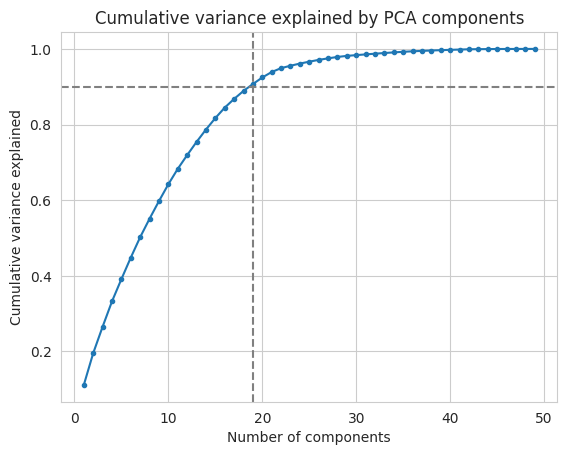

In [ ]:
pca_full = PCA(random_state=SEED).fit(X_vitals_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumulative_var >= 0.90)) + 1

print(f"Components needed for 90% variance: {n_components} (out of {X_vitals_scaled.shape[1]} original columns)")

plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker=".")
plt.axhline(0.90, linestyle="--", color="gray")
plt.axvline(n_components, linestyle="--", color="gray")
plt.title("Cumulative variance explained by PCA components")
plt.xlabel("Number of components"); plt.ylabel("Cumulative variance explained")
plt.show()


In [ ]:
pca = PCA(n_components=n_components, random_state=SEED)
X_vitals = pca.fit_transform(X_vitals_scaled)
print(f"Reduced vitals matrix used for clustering: {X_vitals.shape}")


Reduced vitals matrix used for clustering: (32233, 19)


## 8. Cluster on vitals/labs

K-Means clustering is applied to the PCA-transformed vitals and lab data.

I test values of k from 2 through 7 and use the silhouette score to compare the results. The value of k with the highest silhouette score is selected.


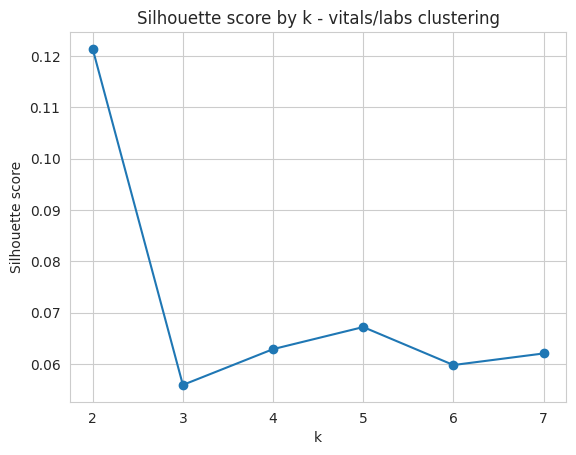

Chosen k for vitals clustering: 2 (silhouette = 0.121)


In [ ]:
k_range = range(2, 8)
silhouettes_vitals = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X_vitals)
    silhouettes_vitals.append(silhouette_score(X_vitals, labels))

plt.plot(list(k_range), silhouettes_vitals, marker="o")
plt.title("Silhouette score by k - vitals/labs clustering")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.show()

k_vitals = list(k_range)[int(np.argmax(silhouettes_vitals))]
best_silhouette_vitals = max(silhouettes_vitals)
print(f"Chosen k for vitals clustering: {k_vitals} (silhouette = {best_silhouette_vitals:.3f})")


The silhouette score is modest, suggesting that the clusters overlap rather than forming clearly separated patient groups.


In [ ]:
kmeans_vitals = KMeans(n_clusters=k_vitals, random_state=SEED, n_init=10)
features["cluster_vitals"] = kmeans_vitals.fit_predict(X_vitals)

print(features["cluster_vitals"].value_counts().sort_index())


cluster_vitals
0    19855
1    12378
Name: count, dtype: int64


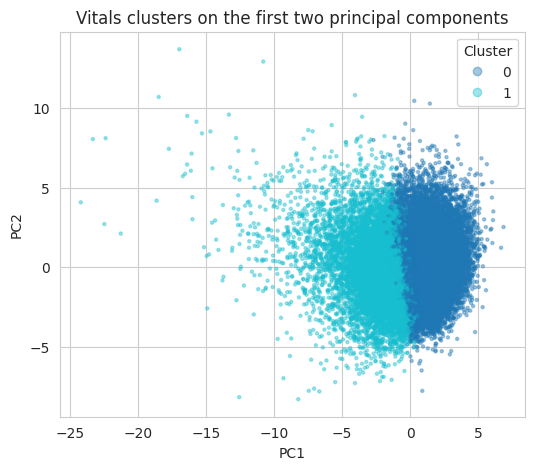

In [ ]:
# quick visual of the clusters on the first two principal components
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_vitals[:, 0], X_vitals[:, 1], c=features["cluster_vitals"],
                       cmap="tab10", s=5, alpha=0.4)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Vitals clusters on the first two principal components")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


## 9. Cluster on comorbidities

K-Means clustering is also applied to the comorbidity features. I test values of k from 2 through 7 and select the value with the highest silhouette score.

One limitation is that K-Means is mainly designed for continuous data, while the comorbidity features are binary (0/1). I use K-Means here to keep the clustering approach consistent across both feature sets.


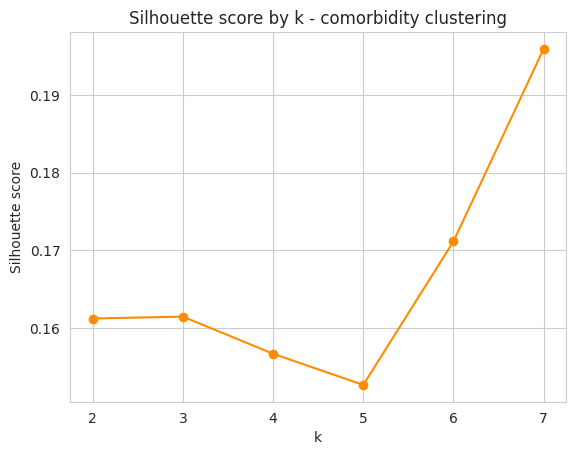

Chosen k for comorbidity clustering: 7 (silhouette = 0.196)


In [ ]:
silhouettes_comorbid = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X_comorbid)
    silhouettes_comorbid.append(silhouette_score(X_comorbid, labels))

plt.plot(list(k_range), silhouettes_comorbid, marker="o", color="darkorange")
plt.title("Silhouette score by k - comorbidity clustering")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.show()

k_comorbid = list(k_range)[int(np.argmax(silhouettes_comorbid))]
best_silhouette_comorbid = max(silhouettes_comorbid)
print(f"Chosen k for comorbidity clustering: {k_comorbid} (silhouette = {best_silhouette_comorbid:.3f})")


In [ ]:
kmeans_comorbid = KMeans(n_clusters=k_comorbid, random_state=SEED, n_init=10)
features["cluster_comorbid"] = kmeans_comorbid.fit_predict(X_comorbid)

print(features["cluster_comorbid"].value_counts().sort_index())


cluster_comorbid
0    2993
1    3169
2    7156
3    3738
4    4004
5    8465
6    2708
Name: count, dtype: int64


## 10. Do the two clusterings agree?

Each patient now has two cluster labels: one based on vitals/labs and one based on comorbidities.

I use Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) to compare the two clustering results. Higher values indicate greater agreement between the two cluster assignments.


In [ ]:
ari = adjusted_rand_score(features["cluster_vitals"], features["cluster_comorbid"])
nmi = normalized_mutual_info_score(features["cluster_vitals"], features["cluster_comorbid"])

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

pd.crosstab(features["cluster_vitals"], features["cluster_comorbid"])


Adjusted Rand Index: 0.012
Normalized Mutual Information: 0.008


cluster_comorbid,0,1,2,3,4,5,6
cluster_vitals,,,,,,,
0,1630,1630,4830,2496,2322,5636,1311
1,1363,1539,2326,1242,1682,2829,1397


Low ARI and NMI values indicate that the vitals/labs and comorbidity feature sets are grouping patients differently. This suggests that the two feature sets capture different characteristics of the ICU population.


With a large cohort (n=32,233), statistical significance alone may not indicate a meaningful difference between clusters.

I therefore also report effect sizes: Cramer's V for mortality and eta-squared for length of stay.


In [ ]:
def profile_clusters(df, cluster_col, outcome_cols=("hospital_expire_flag", "los_hours")):
    summary = df.groupby(cluster_col).agg(
        n=("icustay_id", "count"),
        mortality_rate=("hospital_expire_flag", "mean"),
        los_mean_hours=("los_hours", "mean"),
    )
    return summary.round(3)

print("Vitals clusters:")
print(profile_clusters(features, "cluster_vitals"))
print("\nComorbidity clusters:")
print(profile_clusters(features, "cluster_comorbid"))


Vitals clusters:
                    n  mortality_rate  los_mean_hours
cluster_vitals                                       
0               19855           0.064          89.482
1               12378           0.177         144.626

Comorbidity clusters:
                     n  mortality_rate  los_mean_hours
cluster_comorbid                                      
0                 2993           0.142         140.622
1                 3169           0.169         142.411
2                 7156           0.084          86.358
3                 3738           0.063          99.803
4                 4004           0.104         110.209
5                 8465           0.105         111.956
6                 2708           0.135         116.184


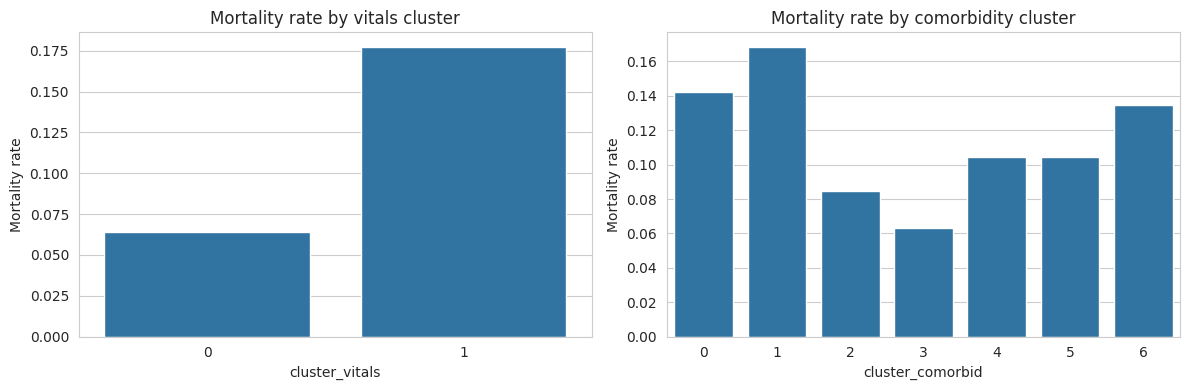

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=features, x="cluster_vitals", y="hospital_expire_flag", ax=axes[0], errorbar=None)
axes[0].set_title("Mortality rate by vitals cluster")
axes[0].set_ylabel("Mortality rate")

sns.barplot(data=features, x="cluster_comorbid", y="hospital_expire_flag", ax=axes[1], errorbar=None)
axes[1].set_title("Mortality rate by comorbidity cluster")
axes[1].set_ylabel("Mortality rate")

plt.tight_layout()
plt.show()


In [ ]:
def cramers_v(chi2, contingency_table):
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

def eta_squared(f_stat, groups):
    n = sum(len(g) for g in groups)
    k = len(groups)
    df_between = k - 1
    df_within = n - k
    return (f_stat * df_between) / (f_stat * df_between + df_within)

print("Mortality (chi-square + Cramer's V):")
for label, col in [("vitals", "cluster_vitals"), ("comorbidity", "cluster_comorbid")]:
    contingency = pd.crosstab(features[col], features["hospital_expire_flag"])
    chi2, p_val, _, _ = stats.chi2_contingency(contingency)
    v = cramers_v(chi2, contingency)
    print(f"  {label}: chi2={chi2:.2f}, p={p_val:.4g}, Cramer's V={v:.3f}")

print("\nLength of stay (ANOVA + eta-squared):")
for label, col in [("vitals", "cluster_vitals"), ("comorbidity", "cluster_comorbid")]:
    groups = [g["los_hours"].values for _, g in features.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    eta2 = eta_squared(f_stat, groups)
    print(f"  {label}: F={f_stat:.2f}, p={p_val:.4g}, eta-squared={eta2:.3f}")


Mortality (chi-square + Cramer's V):
  vitals: chi2=1020.22, p=7.249e-224, Cramer's V=0.178
  comorbidity: chi2=298.56, p=1.664e-61, Cramer's V=0.096

Length of stay (ANOVA + eta-squared):
  vitals: F=1049.56, p=1.318e-226, eta-squared=0.032
  comorbidity: F=78.92, p=2.32e-98, eta-squared=0.014


To better understand the vitals clusters, I compare each cluster's average feature values with the overall population averages. This helps identify which measurements differ the most between the patient groups.


In [ ]:
vitals_profile = features.groupby("cluster_vitals")[vital_lab_cols].mean().T
vitals_profile["overall_mean"] = features[vital_lab_cols].mean()
vitals_profile.round(2)


cluster_vitals,0,1,overall_mean
dbp_mean,62.72,57.18,60.59
gcs_mean,13.52,9.99,11.89
heart_rate_mean,82.79,90.17,85.63
resp_rate_mean,18.47,18.93,18.65
sbp_mean,122.63,113.15,118.99
spo2_mean,97.18,97.53,97.31
temp_c_mean,36.90,36.95,36.93
dbp_min,45.47,37.45,42.39
gcs_min,12.31,6.31,9.55
heart_rate_min,69.17,73.75,70.93


In [ ]:
comorbid_profile = features.groupby("cluster_comorbid")[comorbidity_cols].mean().T
comorbid_profile["overall_rate"] = features[comorbidity_cols].mean()
comorbid_profile.round(2)


cluster_comorbid,0,1,2,3,4,5,6,overall_rate
congestive_heart_failure,0.13,0.46,0.16,0.16,0.36,0.1,0.74,0.24
cardiac_arrhythmia,0.18,1.0,0.0,0.0,1.0,0.0,0.35,0.27
hypertension,0.45,0.0,1.0,0.47,1.0,0.0,0.01,0.44
chronic_pulmonary_disease,0.19,0.23,0.18,0.16,0.21,0.15,0.23,0.18
diabetes,0.2,0.14,0.31,0.22,0.29,0.11,0.81,0.26
renal_failure,0.1,0.14,0.01,0.04,0.01,0.04,0.75,0.1
liver_disease,0.18,0.06,0.05,0.09,0.03,0.09,0.08,0.08
metastatic_cancer,0.1,0.05,0.05,0.08,0.04,0.07,0.03,0.06
solid_tumor,0.05,0.03,0.03,0.05,0.03,0.04,0.02,0.04
coagulopathy,0.1,0.04,0.02,0.05,0.03,0.04,0.05,0.04


## 12. What we found

* The cohort was reduced from 61,532 raw ICU stays to 33,011 after applying the cohort rules, and to 32,233 after the missingness filter.
* PCA reduced the 49 vitals/lab features to 19 principal components while retaining about 90% of the variance.
* Vitals/labs clustering selected k=2 with a silhouette score of 0.121.
* Comorbidity clustering selected k=7 with a silhouette score of 0.196.
* The two clustering approaches showed little agreement, with ARI=0.012 and NMI=0.008.
* Both clustering approaches showed differences in patient outcomes, although the effect sizes were relatively small.

Overall, the results suggest that first-24-hour vitals/labs and comorbidities capture different characteristics of ICU patients.
